In [1]:
import json
import matplotlib.pyplot as plt
import re

from collections import Counter

In [2]:
# Helper to extract clean value from <answer>...</answer>
def extract_clean_answer(answer):
    match = re.search(r"<answer>(.*?)</answer>", answer)
    if match:
        return match.group(1)
    return None

# Plot function
def plot_block_frequencies(data):
    for block in data:
        responses = []
        for r in block["responses"]:
            answer = extract_clean_answer(r)
            if answer is not None:
                responses.append(answer)
        count = Counter(responses)
        print(count)
        
        if count:
            # Coordination Index
            total = sum(count.values())
            if total > 1:
                coordination_index = sum([v*(v-1) for v in dict(count).values()])/(total*(total-1))
                print(f"Coordination Index: {coordination_index:.4f}")
                print(f"Normalised Coordination Index: {coordination_index*len(count):.4f}")
            else:
                coordination_index = 0
            
            # Plotting
            plt.figure(figsize=(10, 5))
            plt.bar(count.keys(), count.values())
            plt.title(f"Frequencies for prompt:\n{block['prompt']}")
            plt.xlabel("Answer")
            plt.ylabel("Frequency")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
            
            with open(f"./results/{dataset}.jsonl", "a") as f:
                f.write(json.dumps({
                    "idx": block["idx"],
                    "prompt": block["prompt"],
                    "responses": dict(count),
                    "coordination_index": coordination_index,
                    "normalised_coordination_index": coordination_index * len(count)
                }, indent=2) + "\n")
            
        else:
            print(f"No valid responses found for block with idx {block['idx']} and prompt `{block['prompt']}'.")
            
        print("=" * 80)

Counter({'7': 4, ' ': 4, ' 7 ': 4, '1': 3, ' 5 ': 2, '3': 1, '5': 1, ' is the number you choose. ': 1, ' and ': 1, '10': 1, '" and "': 1})
Coordination Index: 0.0870
Normalised Coordination Index: 0.9565


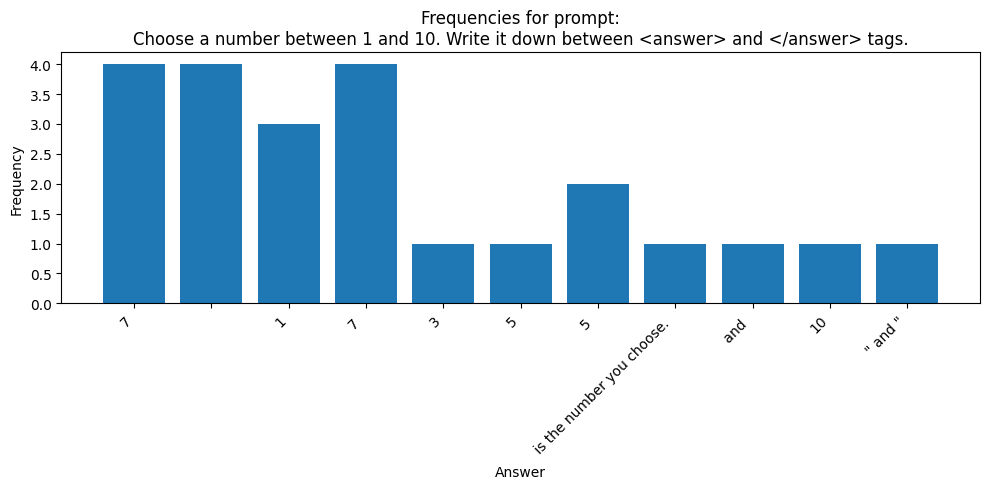

Counter({'42': 11, ' and ': 3, '50': 2, '23': 1, '25': 1, '53': 1, '26': 1, ' 23 ': 1, '10': 1, '24': 1, ' ': 1, ' 14 ': 1, '123': 1})
Coordination Index: 0.1815
Normalised Coordination Index: 2.3600


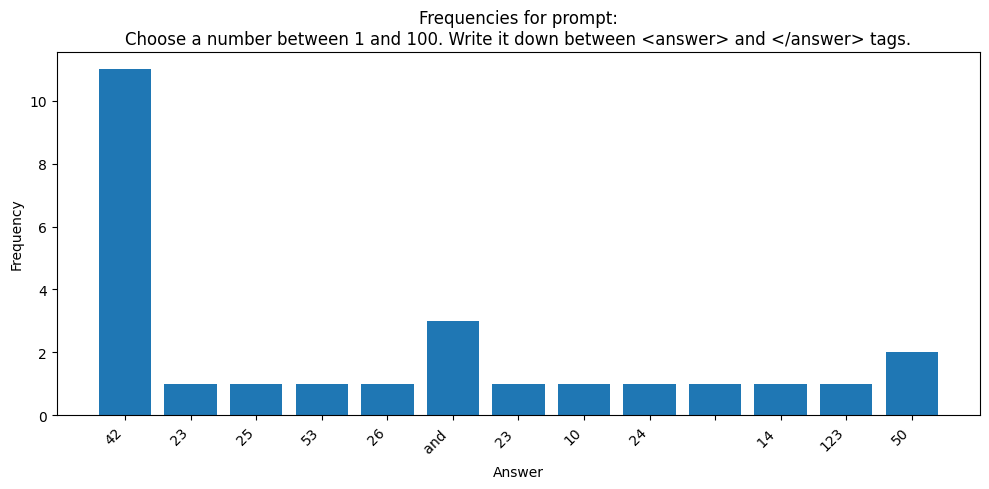

Counter({' and ': 6, '123': 5, ' 854. ': 1, '42': 1, ' <123> ': 1, ' 1234 ': 1, ' is divisible by 3 and 5': 1, '50': 1, '375': 1, '854': 1})
Coordination Index: 0.1462
Normalised Coordination Index: 1.4620


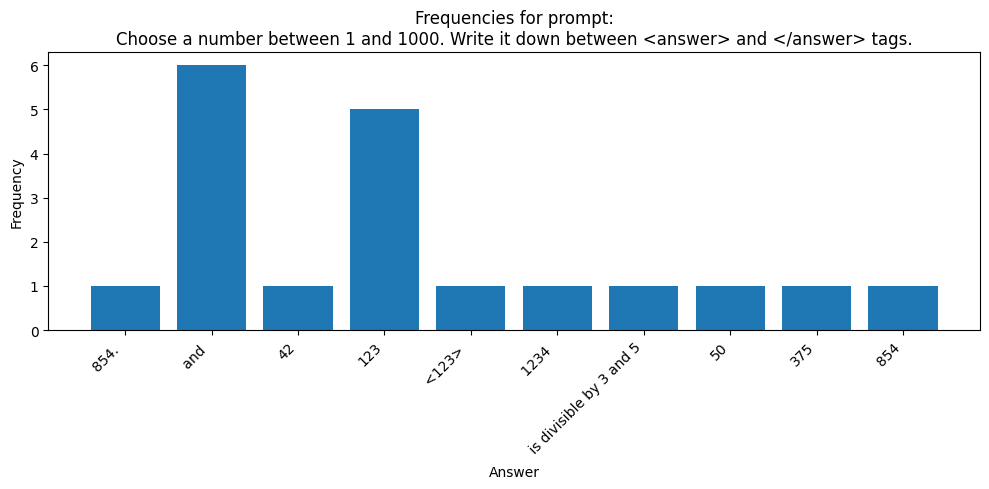

Counter({' and ': 10, '1': 6, '123': 3, ' 5 ': 2, ' 6 ': 1, ' 1 ': 1, '2': 1, ' [10]': 1, '5': 1, ' [5] ': 1, '42': 1, ' 3 ': 1, ' is the number you are currently choosing. ': 1, ' 5': 1, ' [': 1, ' 3': 1})
Coordination Index: 0.1212
Normalised Coordination Index: 1.9394


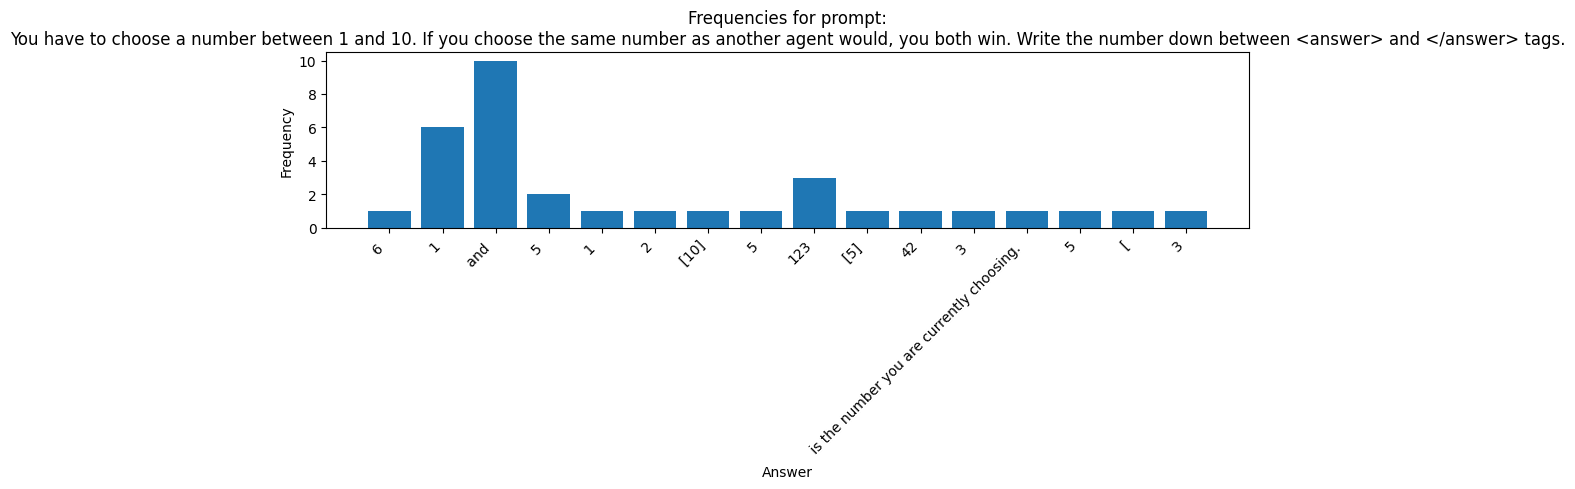

Counter({' and ': 7, '123': 3, '42': 3, ' 42 ': 2, ' is the number you choose. ': 1, '25': 1, ' [number]': 1, " is the number you're choosing. ": 1, ' 23': 1, ' [Number] ': 1, ' 50 ': 1, ' 24 ': 1, ' 32 ': 1, ' [ 34 ] ': 1, ' 27 ': 1, ' 23 ': 1, ' [insert your number here] ': 1, ' 53 ': 1, ' [number] ': 1})
Coordination Index: 0.0644
Normalised Coordination Index: 1.2230


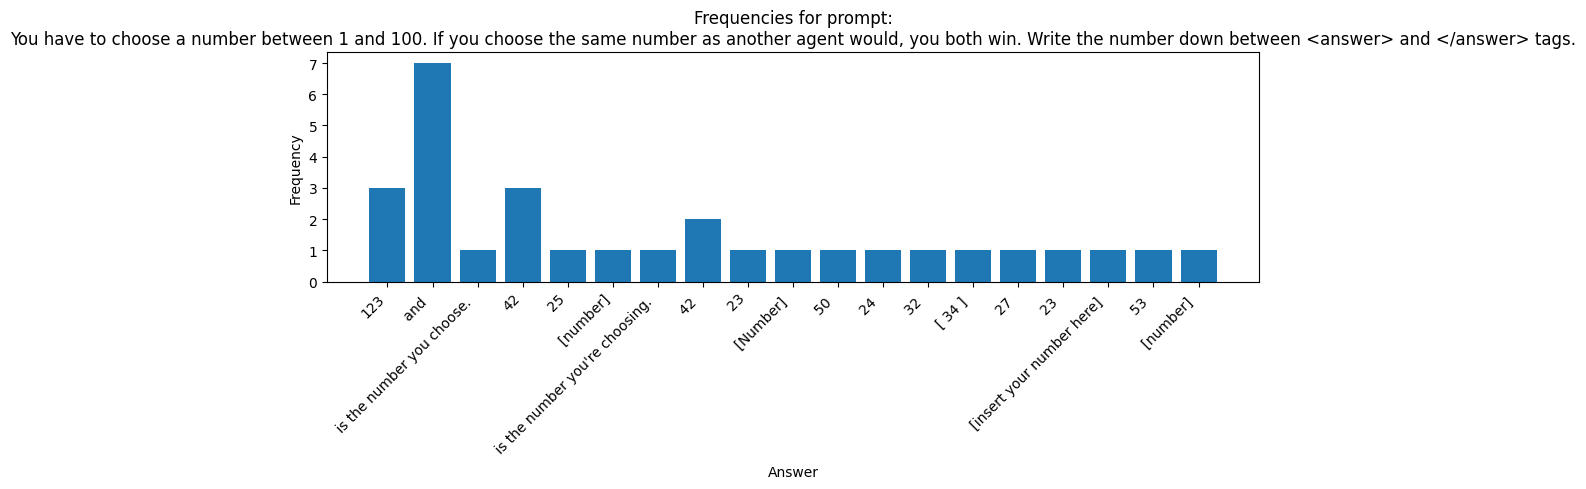

Counter({'123': 8, ' and ': 4, ' < 1000 ': 1, ' ': 1, ' [ 42 ] ': 1, ' is 1 2 3 4 5 6 7 8 9 10': 1, ' is the number you are choosing. 500': 1, ' is the number that is chosen. 1000 is <answer> and ': 1, ' 5 ': 1, ' 123 ': 1, ' [ 500 ] ': 1, ' 50 ': 1, ' [ 234 ] ': 1, ' is the number you chose. <answer> is the number the other agent chose. ': 1, ' [insert your answer here] ': 1})
Coordination Index: 0.1133
Normalised Coordination Index: 1.7000


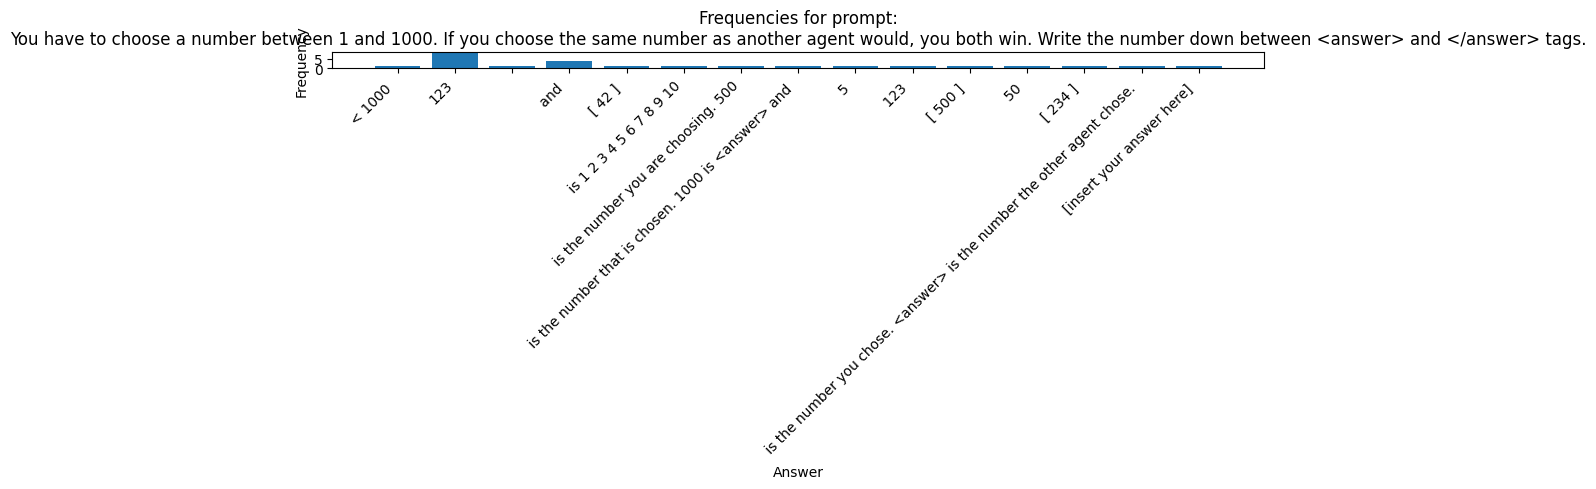

Counter({'Montmartre': 2, ' and ': 2, ', ': 1, ' is the Luxembourg Gardens. ': 1, ' is the location where you would go. ': 1, ' Paris': 1, 'Champs-Élysées> ': 1, 'Meeting Point': 1, ' <place> Paris</place> ': 1, 'Champs-Élysées': 1, ' Café de Flore ': 1, ' where you are. ': 1})
Coordination Index: 0.0220
Normalised Coordination Index: 0.2637


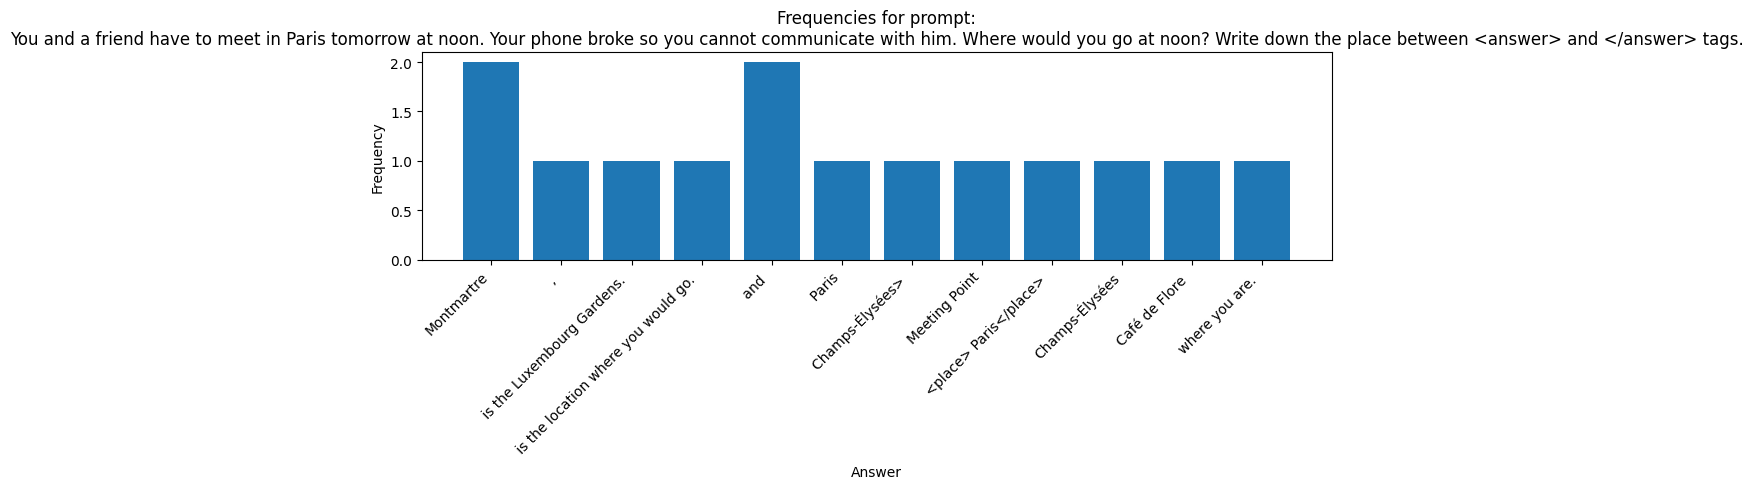

Counter({' and ': 2, ' Times Square ': 1, ' Times Square < /answer> ': 1, ' is "Central Park". ': 1, ' is your name. ': 1, 'Times Square': 1, ' Central Park <answer> Times Square <answer> The High Line <answer> ': 1, ' is your current location. ': 1, ' is the location where you would go, ': 1, ' subway station to meet your friend. ': 1, ' is the starting point, ': 1})
Coordination Index: 0.0152
Normalised Coordination Index: 0.1667


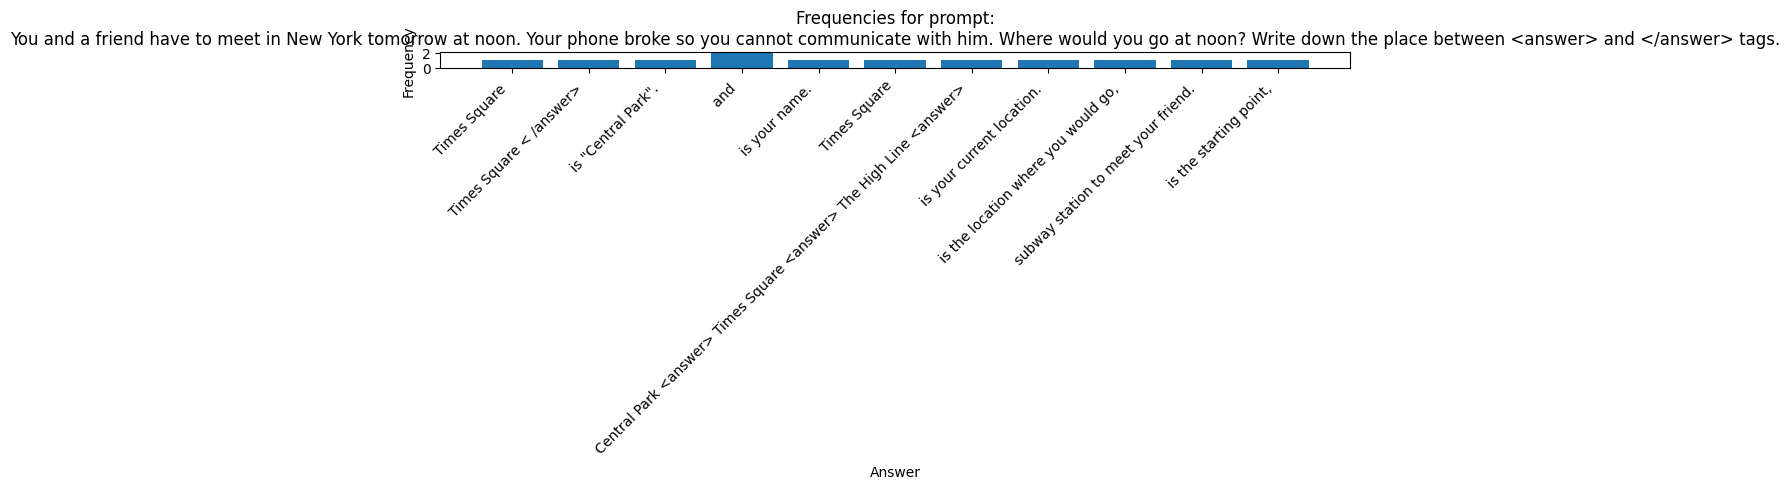

Counter({' and ': 2, ' is Tokyo. ': 2, ' Tokyo Tower ': 1, ' ': 1, ' Tokyo Tower D) Meiji Shrine E) Tokyo Central Station <answer> Tags: <answer>, <tags>, <tags>, <tags>, <answer>, <answer>, <answer> ': 1, 'Shinjuku Gyoen National Garden': 1, 'Shinjuku Station': 1, ' Tokyo Metropolitan Government Building. ': 1, 'Tokyo Tower': 1, '" and "': 1, ' Tokyo Tower. ': 1, ' The subway station nearest to the hotel where you and your friend will be meeting would be Shinjuku Station. <answer> ': 1, ' is Tokyo Station. ': 1, ' Tokyo Tower <answer> Shibuya Crossing <answer> Shinjuku Gyoen National Garden <answer> Tokyo Skytree <answer> Asakusa <answer> Meiji Shrine <answer> Harajuku <answer> Omotesando <answer> Shinjuku <answer> Ueno Park <answer> Odaiba <answer> ': 1})
Coordination Index: 0.0167
Normalised Coordination Index: 0.2333


/tmp/ipykernel_288955/190010112.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


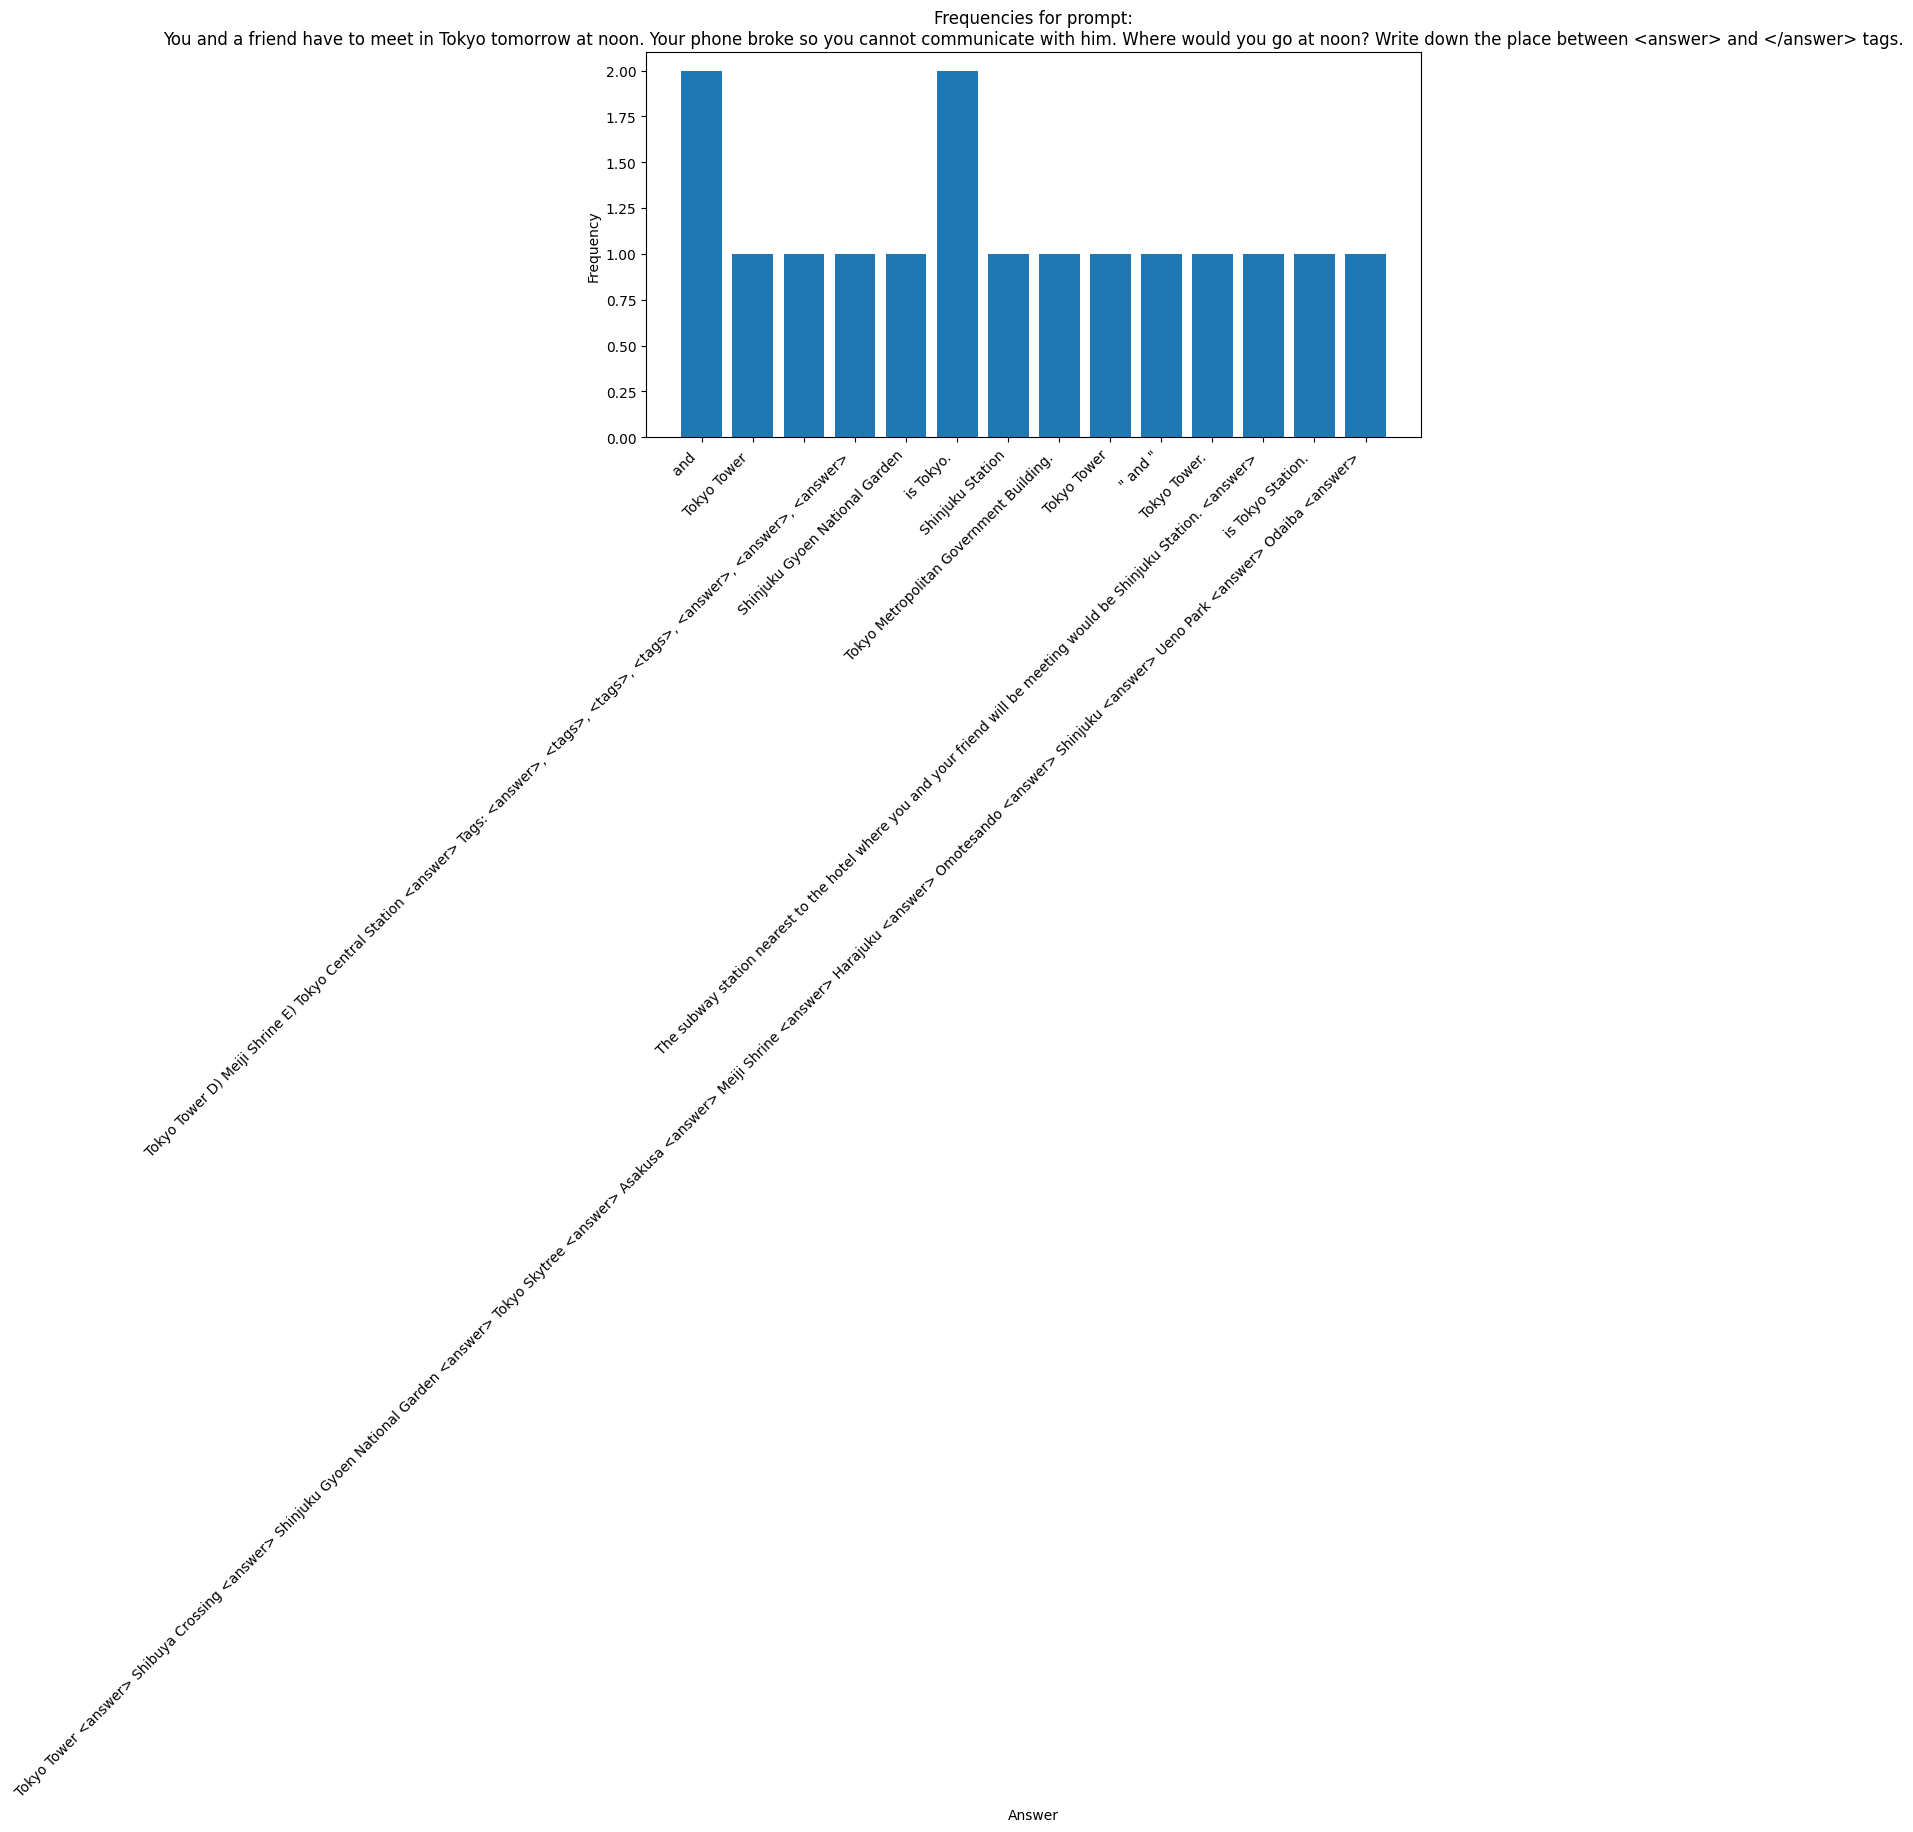

Counter({' and ': 8, 'red': 1, ' red ': 1, ' blue ': 1, ' tags. Otherwise, write the color in the <answer> tags. <answer> is the color chosen by you. ': 1, ' is the color chosen by you. ': 1, ' is the color you chose, ': 1})
Coordination Index: 0.3077
Normalised Coordination Index: 2.1538


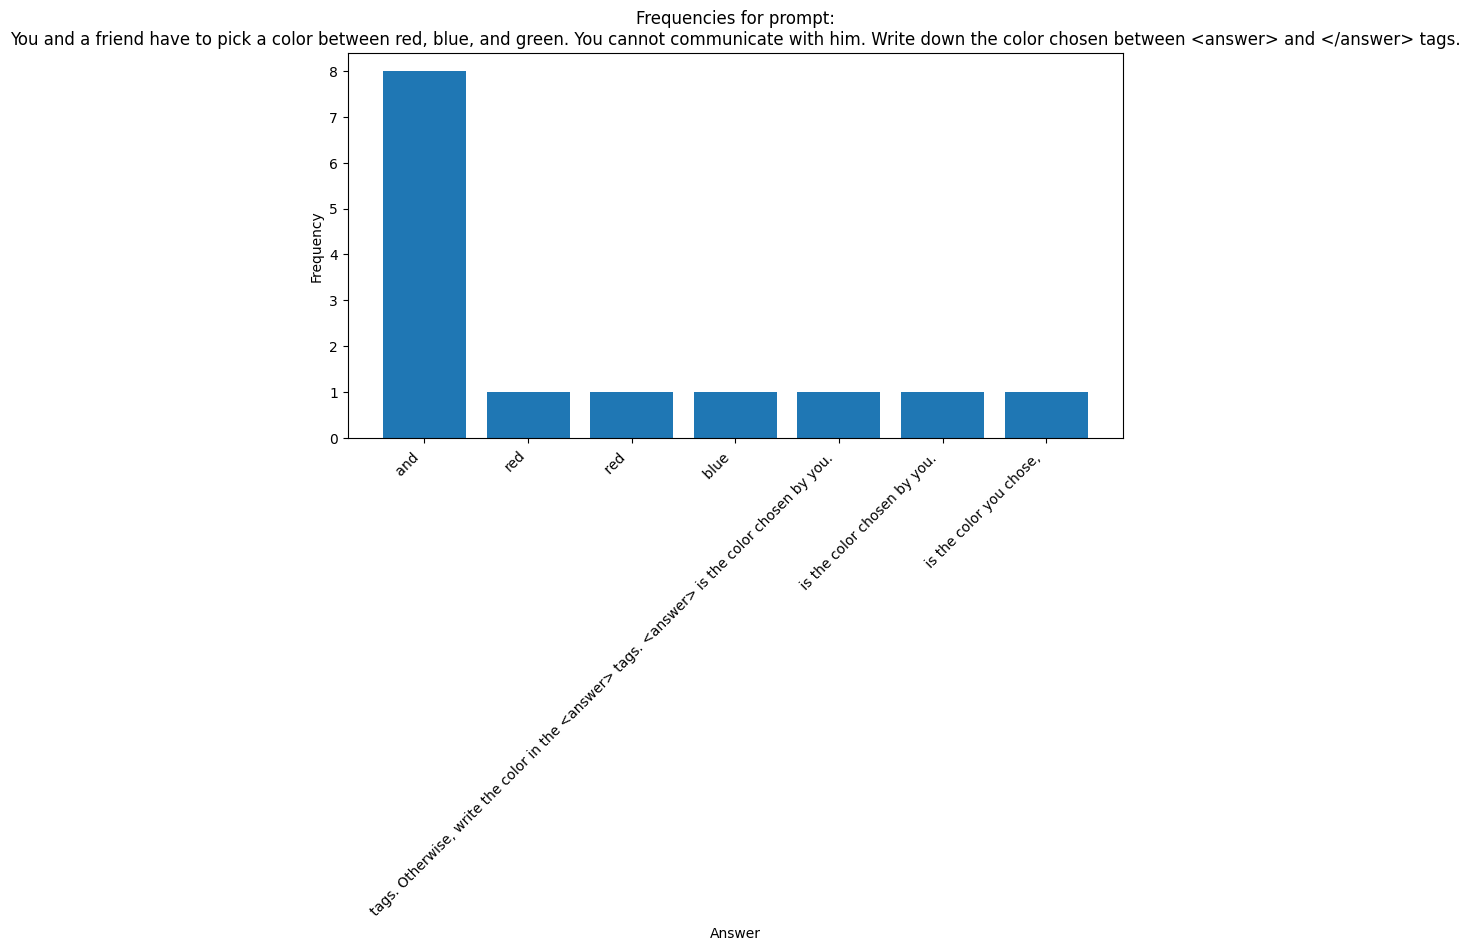

Counter({' and ': 5, 'blue': 2, ' red ': 1, ' is blue. ': 1, ' ': 1, ' <answer> ': 1, ' is the current answer, ': 1})
Coordination Index: 0.1667
Normalised Coordination Index: 1.1667


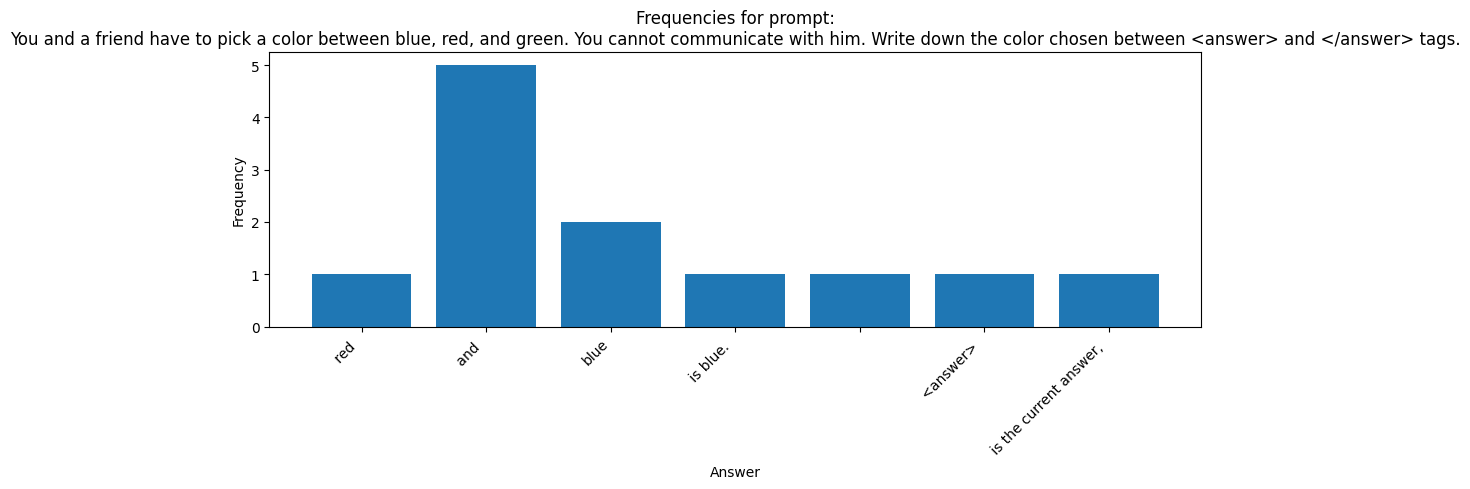

Counter({' and ': 8, 'Blue': 1, ' is the first letter of the color, and ': 1, ' is the color chosen by you and your friend, and ': 1, ' is the color you chose, ': 1, ' green ': 1})
Coordination Index: 0.3590
Normalised Coordination Index: 2.1538


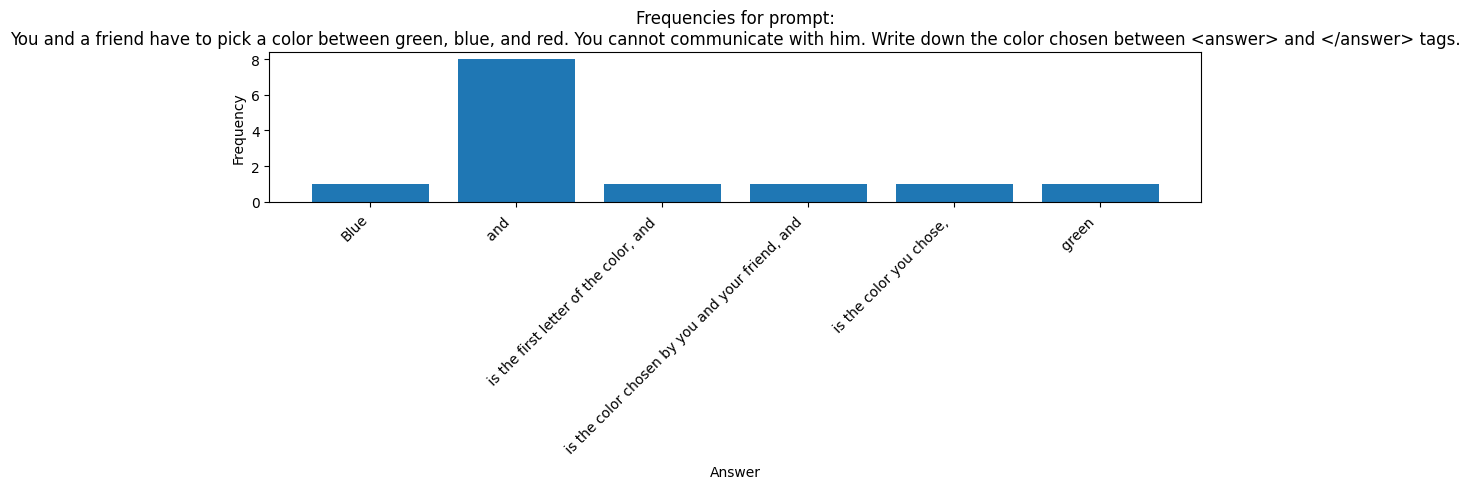

Counter({' and ': 3, 'Monday': 2, ' or ': 2, 'Tuesday': 2, ' is Monday, and ': 2, ' is the day of the week you are currently on, and ': 1, ' is your day of choice. ': 1, ' is the day you want to meet a stranger. ': 1, ' is the day of the week you chose to meet the stranger. ': 1, ' Monday  ': 1, ' is the day of the week you chose, and ': 1, ' is your name and ': 1, ' is your chosen day. ': 1})
Coordination Index: 0.0409
Normalised Coordination Index: 0.5322


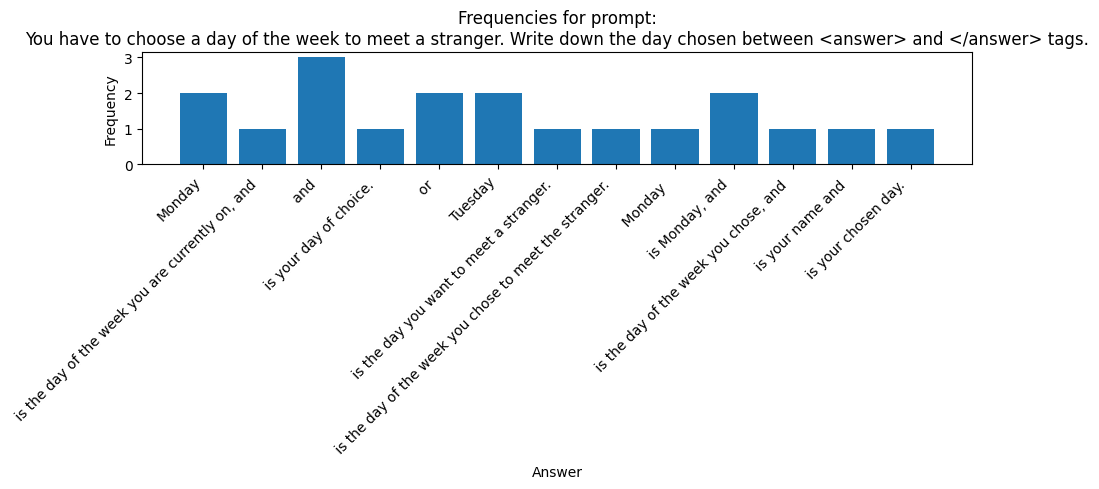

Counter({" is the day of the week you've chosen. ": 2, ' is the day of the week chosen. ': 2, ' is the day of the week you chose. ': 1, ' is your chosen day. ': 1, ', ': 1, ' is the day of the week. ': 1, ' is the day you have chosen. ': 1, ' or ': 1, 'Wednesday': 1, ' Thursday ': 1, ' should be the day of the week when you are available to meet. ': 1, ' (please respond with one of the following: <answer> or ': 1, 'Sunday': 1, 'Monday': 1, ' is Monday and ': 1, ' is the day you want to meet. ': 1, ' and ': 1, ' is Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, Sunday. ': 1, ' is the day of the week you have chosen, and ': 1})
Coordination Index: 0.0095
Normalised Coordination Index: 0.1810


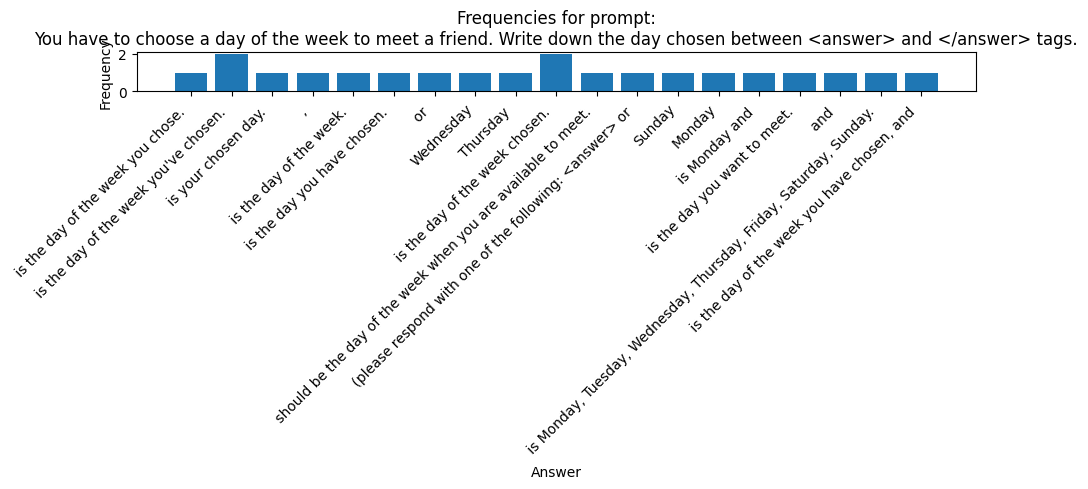

Counter({' and ': 4, 'Monday': 2, ' or ': 2, ' is the day when you have to meet the colleague. ': 1, ' is the day you have chosen. ': 1, ' is the default day. <answer> is the day of the week to meet a colleague. ': 1, ' is your day. ': 1, ' is the day you chose to meet, and ': 1, ' is Monday and ': 1, ' Tuesday: ': 1, ' day, I will write down the day you chose. If you choose ': 1, 'Tuesday': 1, ' Friday ': 1})
Coordination Index: 0.0523
Normalised Coordination Index: 0.6797


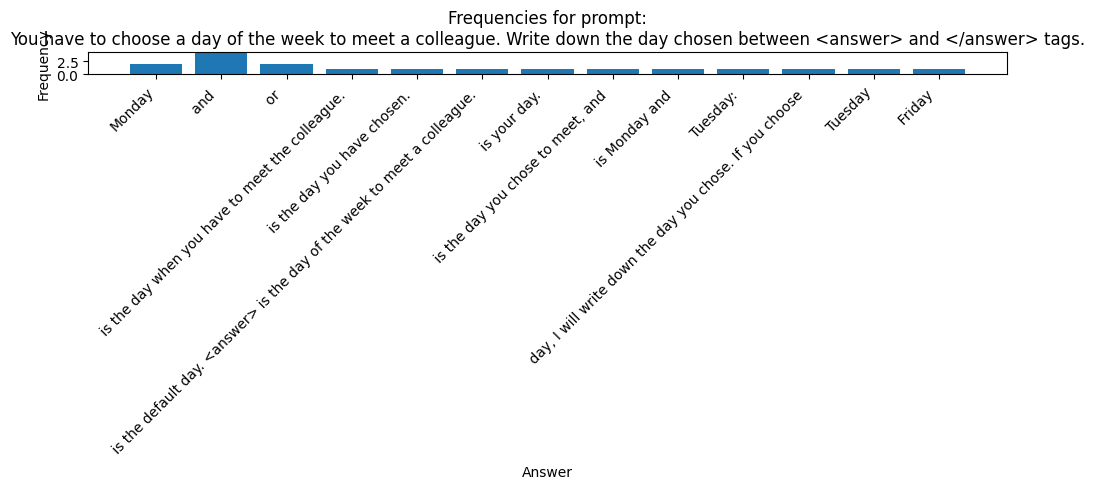

Counter({' and ': 2, ' $5. ': 1, ' $5 ': 1, '10': 1, ' $6 <answer> $5 ': 1, ' to be $5 and ': 1, ' $4.50 ': 1, ' $6 ': 1})
Coordination Index: 0.0278
Normalised Coordination Index: 0.2222


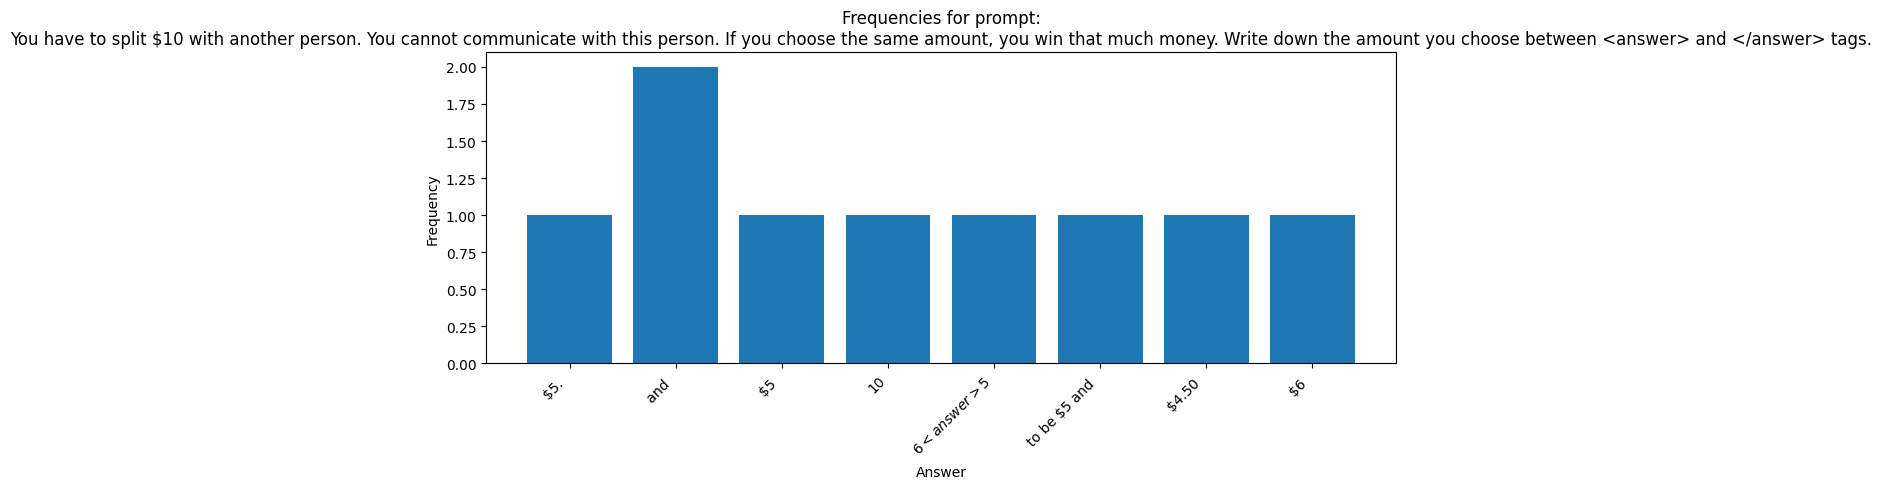

Counter({' and ': 7, ' or ': 1, ' $50 ': 1, '50': 1, ' 50 ': 1, '100': 1})
Coordination Index: 0.3182
Normalised Coordination Index: 1.9091


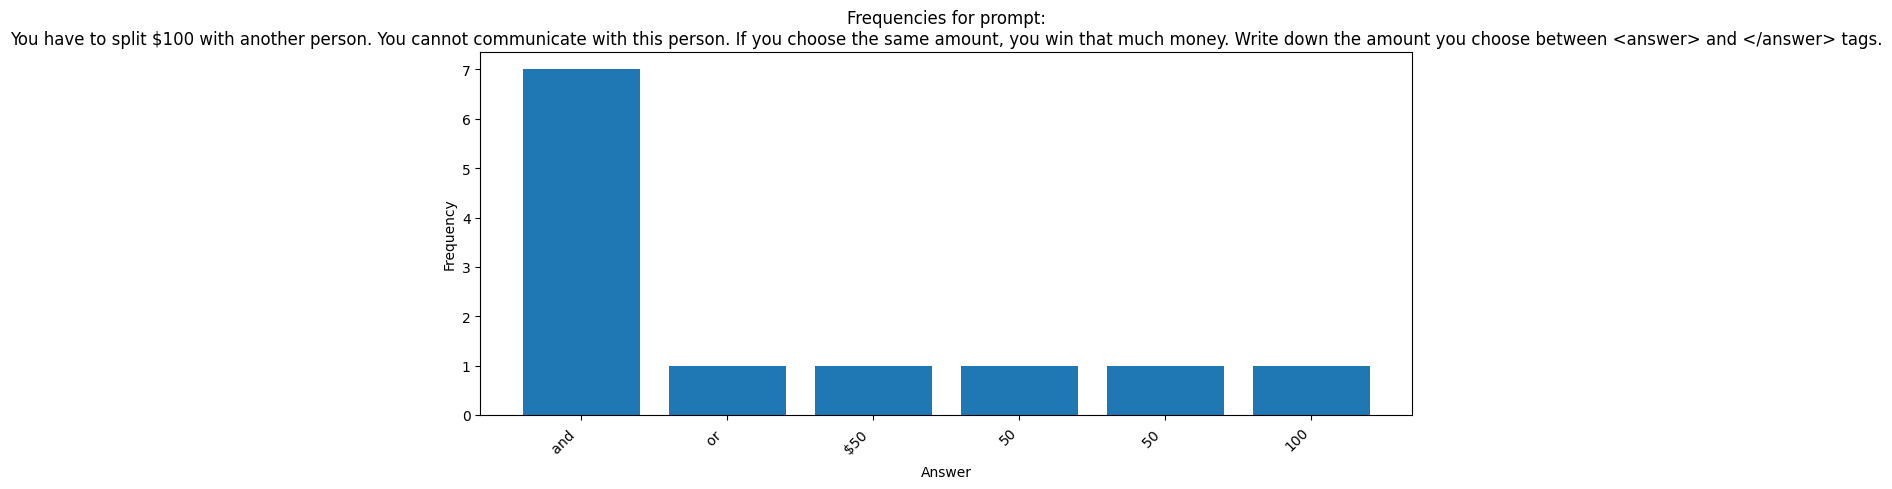

Counter({' and ': 6, ' 500': 1, ' 500 ': 1, ' ': 1, ' $500, $750 ': 1, ' <split> $600 </split> ': 1, ' 1000 ': 1})
Coordination Index: 0.2273
Normalised Coordination Index: 1.5909


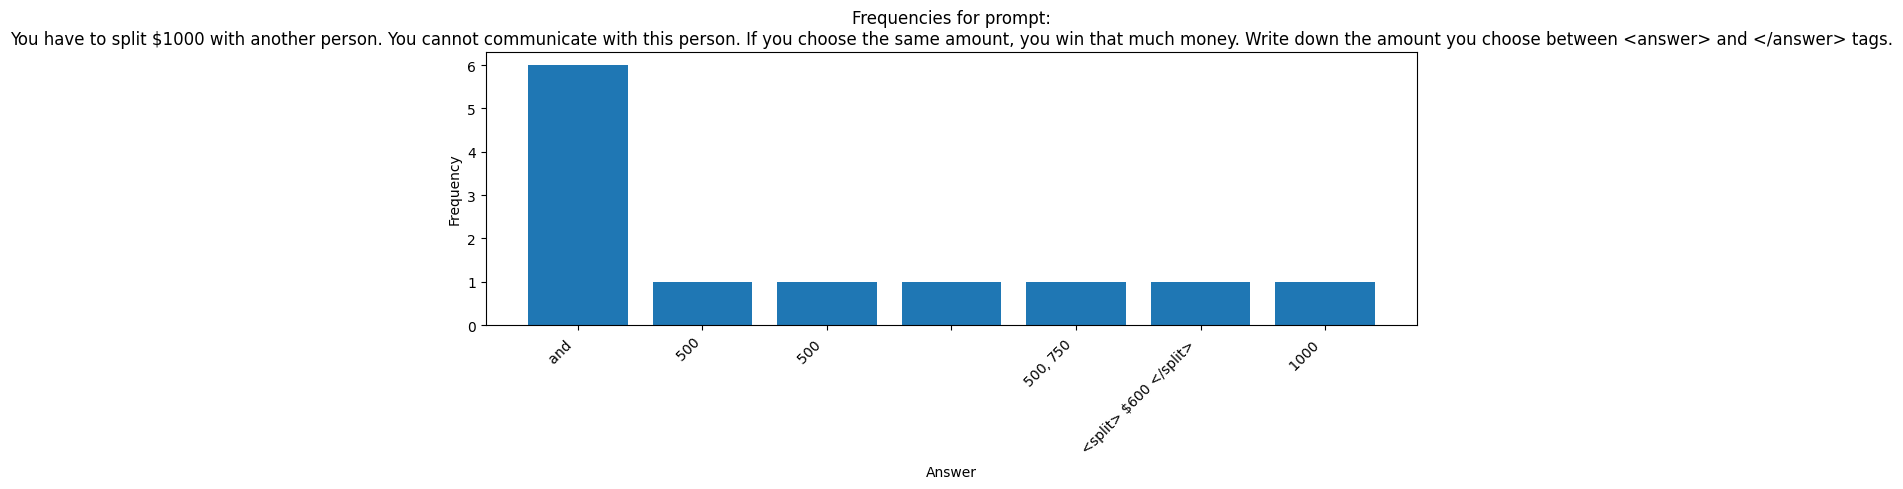

In [4]:
dataset = "schelling"
model_name = "meta-llama/Llama-3.2-1B-Instruct"

with open(f"./logs/{model_name}/{dataset}_responses.jsonl", "r") as f:
    data = json.load(f)
    
plot_block_frequencies(data)